<a href="https://colab.research.google.com/github/JoseTayllan/Mnist/blob/main/Mnist.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf

# Testando importação das camadas e modelos
from tensorflow.keras import models, layers, optimizers, datasets, utils


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

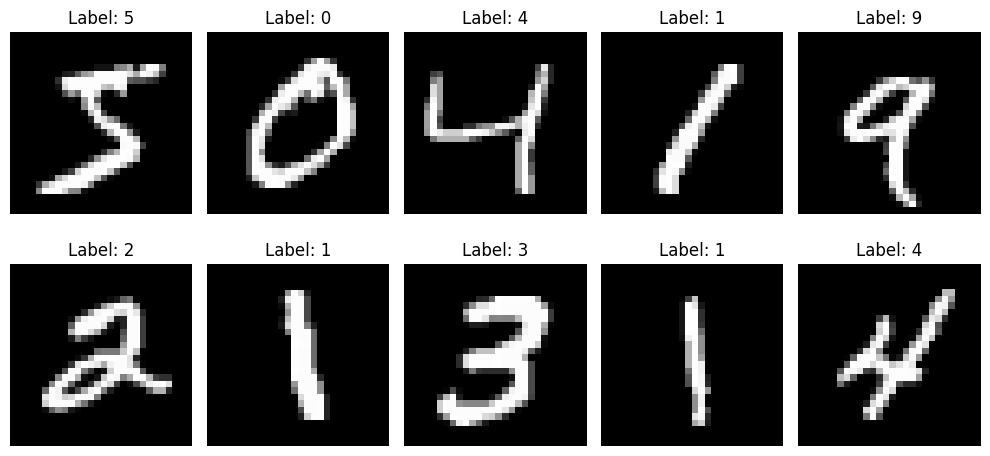

In [ ]:
# --- 1. Carregar e preparar os dados ---
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Normalizar os dados (valores entre 0 e 1)
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Transformar rótulos para one-hot encoding (10 classes)
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# Mostrar algumas imagens do dataset MNIST
plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(f"Label: {np.argmax(y_train[i])}")
    plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
# --- 2. Construir a rede neural ---
def create_model(activation='relu', hidden_layers=[128, 64]):
    model = Sequential()
    model.add(Flatten(input_shape=(28, 28)))  # Camada de entrada (28x28 pixels)

    for units in hidden_layers:
        model.add(Dense(units, activation=activation))  # Camadas ocultas

    model.add(Dense(10, activation='softmax'))  # Camada de saída (10 classes)

    # Compilar o modelo
    model.compile(optimizer=Adam(),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    return model

In [ ]:
# Configurações iniciais
activation_function = 'relu'  # 'relu', 'sigmoid', 'tanh'
hidden_layers = [128, 64]     # Camadas ocultas e neurônios por camada

# Criar o modelo
model = create_model(activation=activation_function, hidden_layers=hidden_layers)

# --- 3. Treinar a rede neural ---
history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.2)


Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8692 - loss: 0.4645 - val_accuracy: 0.9552 - val_loss: 0.1518
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9648 - loss: 0.1174 - val_accuracy: 0.9676 - val_loss: 0.1050
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9765 - loss: 0.0784 - val_accuracy: 0.9690 - val_loss: 0.1044
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9832 - loss: 0.0564 - val_accuracy: 0.9723 - val_loss: 0.0961
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9878 - loss: 0.0407 - val_accuracy: 0.9723 - val_loss: 0.1086
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9898 - loss: 0.0324 - val_accuracy: 0.9711 - val_loss: 0.1035
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9900 - loss: 0.0287 - val_accuracy: 0.9759 - val_loss: 0.0972
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9923 - loss: 0.0

In [ ]:
# --- 4. Avaliar o desempenho ---
loss, accuracy = model.evaluate(X_test, y_test)
print(f"\nTest Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

# --- 5. Plotar os gráficos de perda e acurácia ---
plt.figure(figsize=(12, 5))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9740 - loss: 0.0992

Test Loss: 0.0948
Test Accuracy: 0.9764


<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

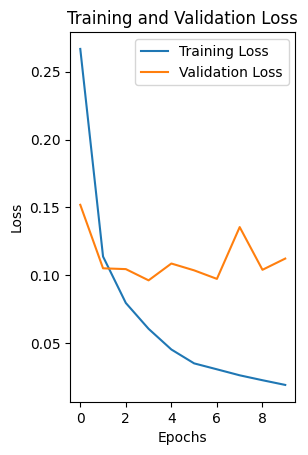

In [ ]:
# Gráfico de perda
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()


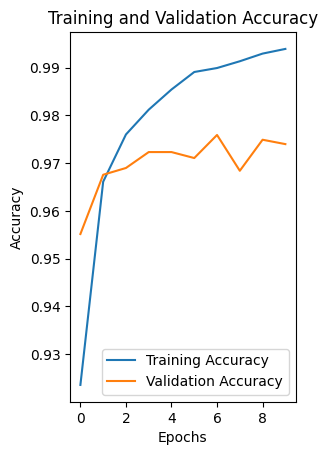

In [ ]:
# Gráfico de acurácia
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()